# 01_data_exploration.ipynb

**Project:** Predictive Maintenance - Engine Failure Prediction
**Author:** Leart Ajro
**Purpose** This notebook will:
                    - Load the engine sensor data
                    - Explore the data (shape,columns, summary statistics)
                    - Check for missing values
                    - visualize key sensor features
                    - prepare the data for modeling

In [6]:
# import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# load data

df = pd.read_csv('../data/ai4i2020.csv')

In [8]:
# quick view of data statistics 

df.head()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## intial exploration findings

- this data set presents **10,000** total rows (machine observations). 

- there are **14 columns**, including sensor measurements and the failure label.

- this is a manageable dataset for classification modeling and exploratory analysis.

- the target variable is **machine failure** making this a binary classification problem.

- sensor based numeric features include temperature, torque, rotational speed, and tool wear.

- Identifier columns such as 'UDI' and 'Product ID' will be removed since they do not contribute to prediction 

- Failure mode columns ('TWF', 'HDF', 'OSF', 'RNF') may cause data leaksage and will not be used as model inputs.

In [9]:
# Feature and target variables

target = 'Machine failure'

features = ['Air temperature [K]', 
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]',
           ]

X = df[features] 
y = df[target] 

print((y.value_counts(normalize=True).sort_index()*100).round(2))

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


## Class distribution

- No failure (0) : 9,661 entries (96.61%)
- Failure (1) : 339 entries (3.39%)

This is a highly imbalanced data set

## 1. Visualization Strategy

To better understand this data set, I will:

1. Visualize each sensor's distribution using histograms and boxplots to assess spread, skewness, and potential outliers.

2. Compare sensor distriubtions across machine failure classes (0 vs 1) using boxplots or overlaid histograms to identify differences in behavior between failing and non-failing machines.

3. Use scatter plots to evaluate relationships between pairs of sensor features and assess potential correlations.

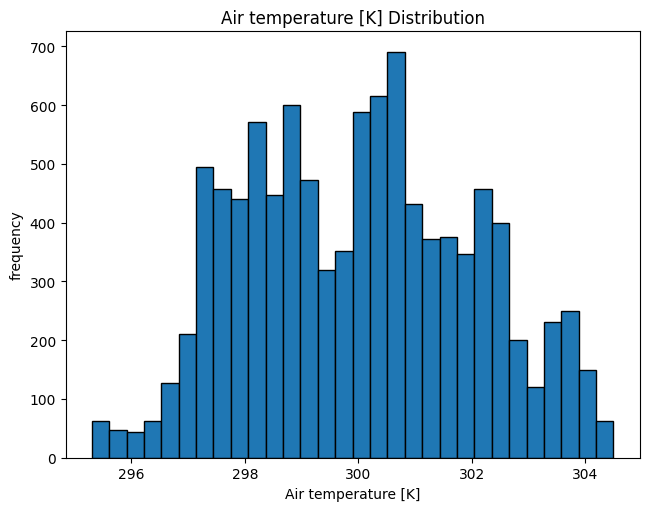

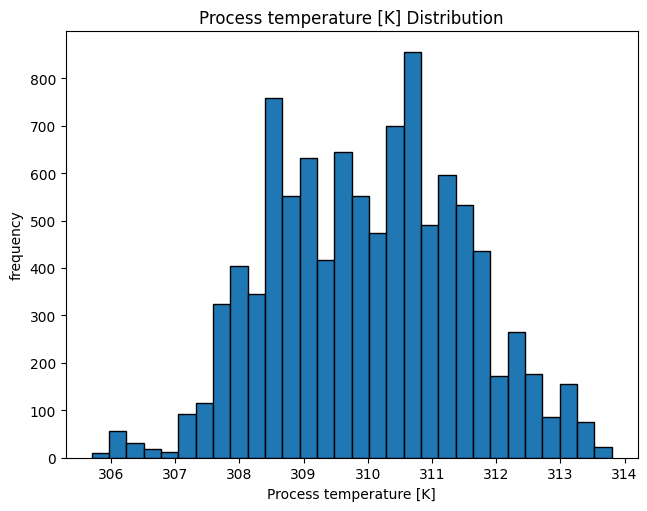

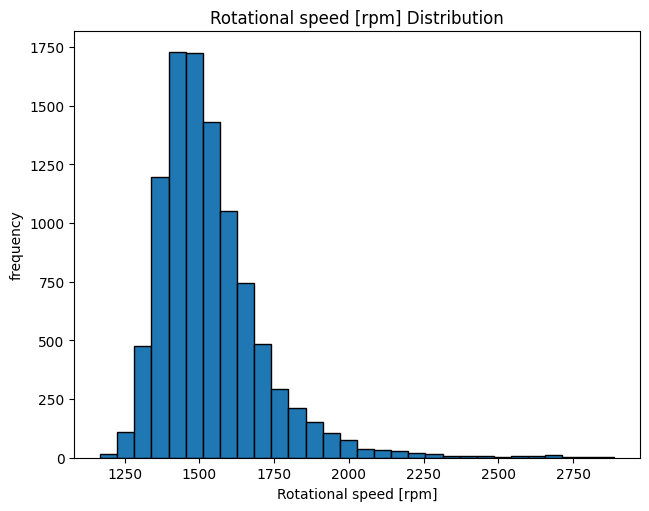

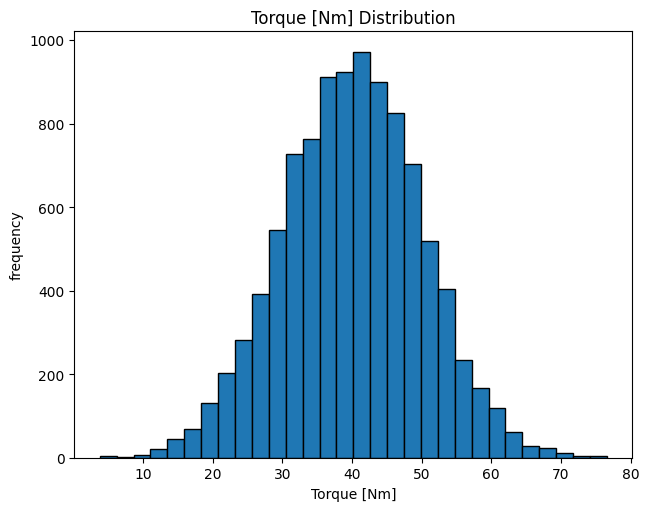

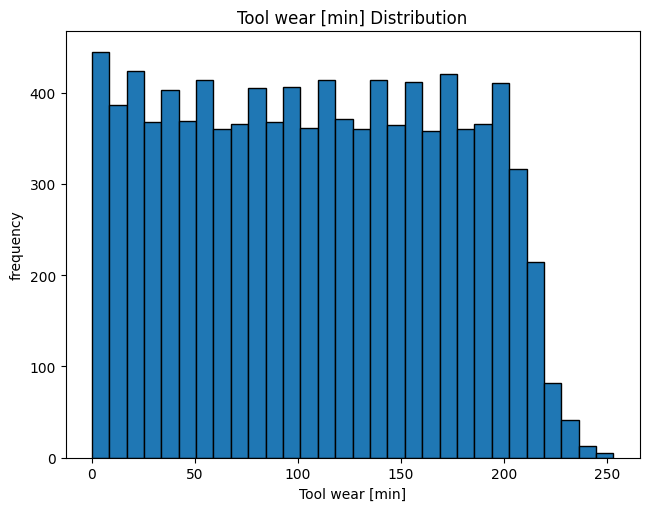

In [10]:
# Feature Distribution Visualization - Histograms

for feature in features: 
       plt.figure()          
       plt.hist(df[feature], bins=30, edgecolor='black') 
       plt.tight_layout()
       plt.title(f'{feature} Distribution')
       plt.xlabel(feature) 
       plt.ylabel('frequency') 
       plt.show() 

## Feature Distribution Findings

- **Air temperature** and **process temperature** show relatively symmetric distributions.

- **Rotational speed** is right-skewed, indicating the presence of higher-speed tail observations.

- No extreme abnormal spikes were observed in temperature features.

- **Rotational speed** may require scaling or transformation during preproccessing

- **Torque** follows a near-normal (bell shaped) distribution and appears well-behaved.

- **Tool wear** displays a broad, fairly uniform spread with a sharp drop off at higher values, likely reflecting operational or 
maintenance limits.

Overall, most features appear well distributed, with rotational speed being the most skewed. Further analysis will examine how these sensor readings differ between failure and non-failure machines.

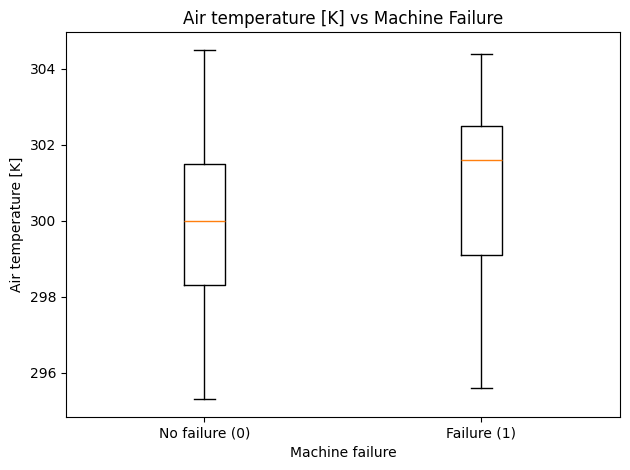

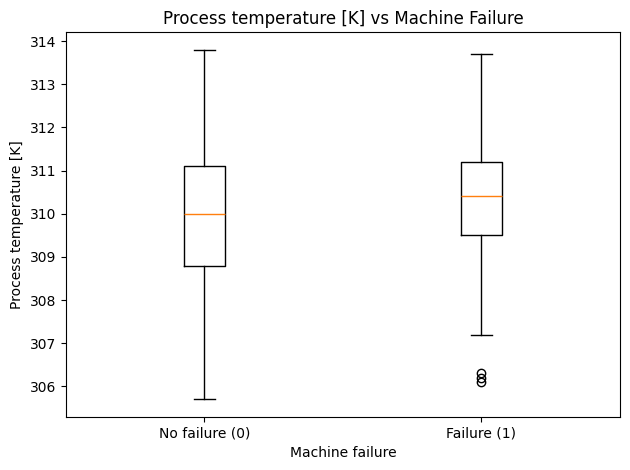

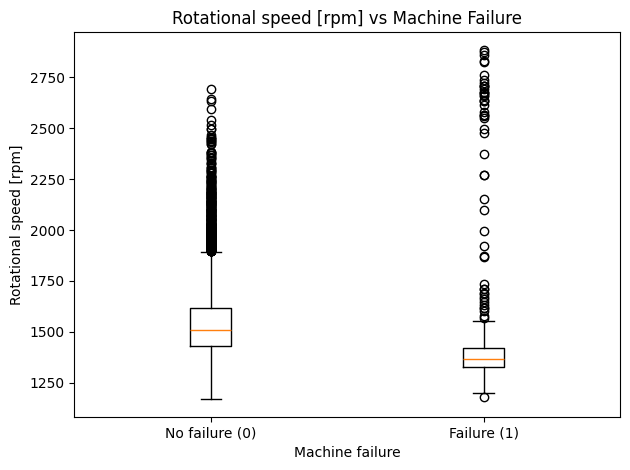

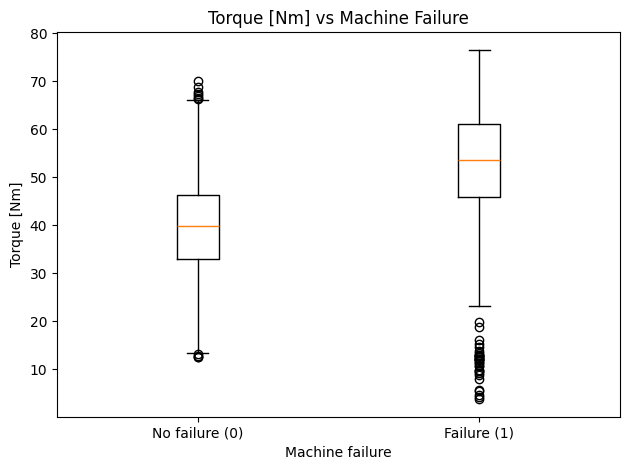

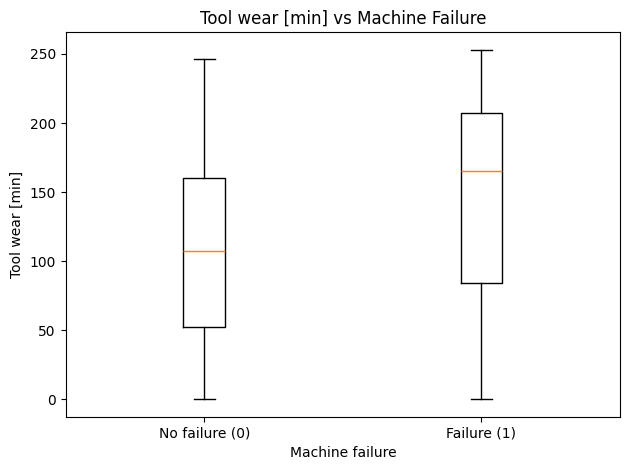

In [11]:
# Class Seperation Visualization - Boxplot

for feature in features:
    plt.figure() 
    class0_data = df[df[target] == 0][feature]
    class1_data = df[df[target] == 1][feature]
    plt.boxplot([class0_data, class1_data])
    plt.xticks([1,2], ['No failure (0)', 'Failure (1)'])
    plt.title(f'{feature} vs Machine Failure')
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## Feature vs Target Analysis (Sensor vs Machine Failure)

Boxplots were used to compare the distribution of each sensor feature 

## Key findings 

- **Rotatinal Speed [rpm]**
 - Strong downward median
 - minimal overlap between distributions
 - indicates machines tend to fail at lower rpms
 - strong predictive signal 

- **Torque [Nm]**
 - Strong upward median shift 
 - Very little overlap between IQRs
 - suggests higher mechanical load is associated with failure
 - strong predictive signal 

 - **Tool Wear [min]**
  - Clear upward median shift in failure class
  - Noticeable overlap between distributions
  - Indicates accumulated wear contributes to failure risk
  - Moderate predictive signal

- **Air Temperature [K]**
  - Slight median shift
  - Heavy overlap between distributions
  - Weak predictive signal

- **Process Temperature [K]**
  - Nearly identical distributions across classes
  - Minimal separation
  - Very weak predictive signal


### Overall Interpretation

The most informative features appear to be:
- Rotational Speed
- Torque

These features show strong class separation and likely capture meaningful mechanical behavior.

A key interaction insight:
- Failures tend to occur under **low rotational speed and high torque**, suggesting mechanical resistance or strain.

Temperature features show limited discriminative power, likely due to controlled operating conditions in industrial systems.
 
